# Streaming Data Load

Load `.npz` dumps, separate calibration from science, fftshift,
pair by LO frequency, and extract frequency-switched HI profiles.

Works with any number of LO frequencies (2 for galactic, 4 for M31).

In [1]:
from pathlib import Path
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np

SAMPLE_RATE_HZ = 2.56e6
NFFT = 1024
HI_REST_MHZ = 1420.405
C_KMS = 299792.458

%matplotlib inline
plt.rcParams.update({'figure.dpi': 130, 'figure.facecolor': 'white'})

## 1. Load dumps

In [2]:
TARGET = 'm31'
DATA_DIR = Path(f'../../../data/lab04/streaming/{TARGET}')
paths = sorted(DATA_DIR.glob(f'{TARGET}_dump_*.npz'))
N = len(paths)
print(f'{N} dumps in {DATA_DIR}')

with np.load(paths[0], allow_pickle=True) as f:
    N_CH = f['corr01'].shape[0]
    print(f'Keys: {list(f.keys())}')

# Load all
corr00 = np.empty((N, N_CH), dtype=float)
corr11 = np.empty((N, N_CH), dtype=float)
lo_mhz = np.empty(N)
noise_on = np.empty(N, dtype=bool)
unix_t = np.empty(N)
alt_arr = np.empty(N)
az_arr = np.empty(N)

for i, p in enumerate(paths):
    with np.load(p, allow_pickle=True) as f:
        corr00[i] = f['corr00']
        corr11[i] = f['corr11']
        lo_mhz[i] = float(f['lo_freq_mhz'])
        noise_on[i] = bool(f['noise_on'])
        unix_t[i] = float(f['time'])
        alt_arr[i] = float(f['alt_deg'])
        az_arr[i] = float(f['az_deg'])

# Separate
cal = noise_on
sci = ~noise_on
lo_unique = sorted(set(lo_mhz[sci]))

print(f'Cal: {cal.sum()}, Science: {sci.sum()}')
print(f'LO frequencies: {lo_unique} MHz')
for lo in lo_unique:
    print(f'  LO={lo}: {(sci & (lo_mhz == lo)).sum()} science dumps')

714 dumps in ../../../data/lab04/streaming/m31
Keys: ['corr00', 'corr01', 'corr11', 'time', 'lo_freq_mhz', 'noise_on', 'target_name', 'alt_deg', 'az_deg', 'ra_deg', 'dec_deg', 'seq']
Cal: 20, Science: 694
LO frequencies: [np.float64(1420.0), np.float64(1421.0), np.float64(1422.0), np.float64(1423.0), np.float64(1424.0)] MHz
  LO=1420.0: 140 science dumps
  LO=1421.0: 140 science dumps
  LO=1422.0: 138 science dumps
  LO=1423.0: 138 science dumps
  LO=1424.0: 138 science dumps


## 2. fftshift + mask DC

In [3]:
# fftshift (complex I/Q FFT: reorder to [-fs/2, ..., +fs/2])
corr00 = np.fft.fftshift(corr00, axes=-1)
corr11 = np.fft.fftshift(corr11, axes=-1)

# Mask DC bin (LO spike at channel 512 after fftshift)
DC_BIN = NFFT // 2
corr00[:, DC_BIN] = np.nan
corr11[:, DC_BIN] = np.nan

# Mask the channel at sky frequency 1420.0 MHz exactly (per dump)
# plus 3 bins below (lower frequency side)
MASK_SKY_MHZ = 1420.0
f_bb_mhz = np.fft.fftshift(np.fft.fftfreq(NFFT, d=1.0/SAMPLE_RATE_HZ)) / 1e6
for lo in set(lo_mhz):
    bb_target = MASK_SKY_MHZ - lo
    ch_center = np.argmin(np.abs(f_bb_mhz - bb_target))
    chs_to_mask = [ch_center - 3, ch_center - 2, ch_center - 1, ch_center]
    chs_to_mask = [c for c in chs_to_mask if 0 <= c < NFFT and c != DC_BIN]
    if not chs_to_mask:
        continue
    lo_rows = np.where(lo_mhz == lo)[0]
    for ch in chs_to_mask:
        corr00[lo_rows, ch] = np.nan
        corr11[lo_rows, ch] = np.nan
    print(f'Masked ch {chs_to_mask} (sky {lo + f_bb_mhz[chs_to_mask[0]]:.3f}–'
          f'{lo + f_bb_mhz[chs_to_mask[-1]]:.3f} MHz) for LO={lo}')

# Stokes I = total intensity (both polarisations)
stokes_I = corr00 + corr11

# Baseband frequency axis (fftshifted)
df_khz = SAMPLE_RATE_HZ / NFFT / 1e3

print(f'Baseband: [{f_bb_mhz[0]:.3f}, {f_bb_mhz[-1]:.3f}] MHz')
print(f'dnu = {df_khz:.2f} kHz, dv = {C_KMS * df_khz*1e3 / (HI_REST_MHZ*1e6):.2f} km/s')
print(f'Masked DC bin: channel {DC_BIN}')

Masked ch [np.int64(509), np.int64(510), np.int64(511)] (sky 1419.993–1419.997 MHz) for LO=1420.0
Masked ch [np.int64(109), np.int64(110), np.int64(111), np.int64(112)] (sky 1419.993–1420.000 MHz) for LO=1421.0
Masked ch [np.int64(0)] (sky 1420.720–1420.720 MHz) for LO=1422.0
Masked ch [np.int64(0)] (sky 1421.720–1421.720 MHz) for LO=1423.0
Masked ch [np.int64(0)] (sky 1422.720–1422.720 MHz) for LO=1424.0
Baseband: [-1.280, 1.278] MHz
dnu = 2.50 kHz, dv = 0.53 km/s
Masked DC bin: channel 512


## 2a. RFI flagging

Rolling median + MAD filter on each dump's Stokes I spectrum.
Channels that spike > 5σ above the local median are NaN-masked.

In [4]:
from scipy.ndimage import median_filter

RFI_WINDOW = 15    # channels (~52 kHz) for rolling median
RFI_SIGMA  = 5.0   # flag threshold in units of local MAD

n_flagged_total = 0
for i in range(N):
    spec = stokes_I[i]
    local_med = median_filter(spec, size=RFI_WINDOW)
    resid = spec - local_med
    mad = np.nanmedian(np.abs(resid))
    sigma = mad / 0.6745
    bad = resid > RFI_SIGMA * sigma  # positive spikes only
    n_bad = np.sum(bad)
    if n_bad > 0:
        stokes_I[i, bad] = np.nan
        n_flagged_total += n_bad

# Summary: which channels were flagged across all dumps
flagged_any = np.any(np.isnan(stokes_I), axis=0)
flagged_chs = np.where(flagged_any)[0]
# Exclude DC bin from the report
rfi_chs = flagged_chs[flagged_chs != DC_BIN]

print(f'RFI flagging: {n_flagged_total} samples masked across {N} dumps')
print(f'Channels with any flags (excl. DC): {len(rfi_chs)}')
if len(rfi_chs) > 0:
    # Group into contiguous bands for readability
    bands = []
    start = rfi_chs[0]
    prev = rfi_chs[0]
    for ch in rfi_chs[1:]:
        if ch == prev + 1:
            prev = ch
        else:
            bands.append((start, prev))
            start = ch
            prev = ch
    bands.append((start, prev))
    for b_start, b_end in bands:
        f_lo = f_bb_mhz[b_start]
        f_hi = f_bb_mhz[b_end]
        width = b_end - b_start + 1
        print(f'  ch {b_start}–{b_end} ({width} ch)  '
              f'baseband [{f_lo:+.3f}, {f_hi:+.3f}] MHz')

RFI flagging: 11526 samples masked across 714 dumps
Channels with any flags (excl. DC): 797
  ch 0–0 (1 ch)  baseband [-1.280, -1.280] MHz
  ch 75–75 (1 ch)  baseband [-1.093, -1.093] MHz
  ch 102–114 (13 ch)  baseband [-1.025, -0.995] MHz
  ch 116–128 (13 ch)  baseband [-0.990, -0.960] MHz
  ch 130–138 (9 ch)  baseband [-0.955, -0.935] MHz
  ch 140–511 (372 ch)  baseband [-0.930, -0.003] MHz
  ch 513–863 (351 ch)  baseband [+0.003, +0.877] MHz
  ch 865–888 (24 ch)  baseband [+0.882, +0.940] MHz
  ch 891–893 (3 ch)  baseband [+0.948, +0.953] MHz
  ch 896–896 (1 ch)  baseband [+0.960, +0.960] MHz
  ch 900–902 (3 ch)  baseband [+0.970, +0.975] MHz
  ch 904–905 (2 ch)  baseband [+0.980, +0.983] MHz
  ch 908–908 (1 ch)  baseband [+0.990, +0.990] MHz
  ch 910–910 (1 ch)  baseband [+0.995, +0.995] MHz
  ch 912–912 (1 ch)  baseband [+1.000, +1.000] MHz
  ch 966–966 (1 ch)  baseband [+1.135, +1.135] MHz


## 2b. Mean Stokes I per LO band

/tmp/ipykernel_819211/1069822221.py:9: RuntimeWarning: Mean of empty slice
  mean_sci = np.nanmean(stokes_I[sci_mask], axis=0)
/tmp/ipykernel_819211/1069822221.py:15: RuntimeWarning: Mean of empty slice
  mean_cal = np.nanmean(stokes_I[cal_mask], axis=0)
/tmp/ipykernel_819211/1069822221.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


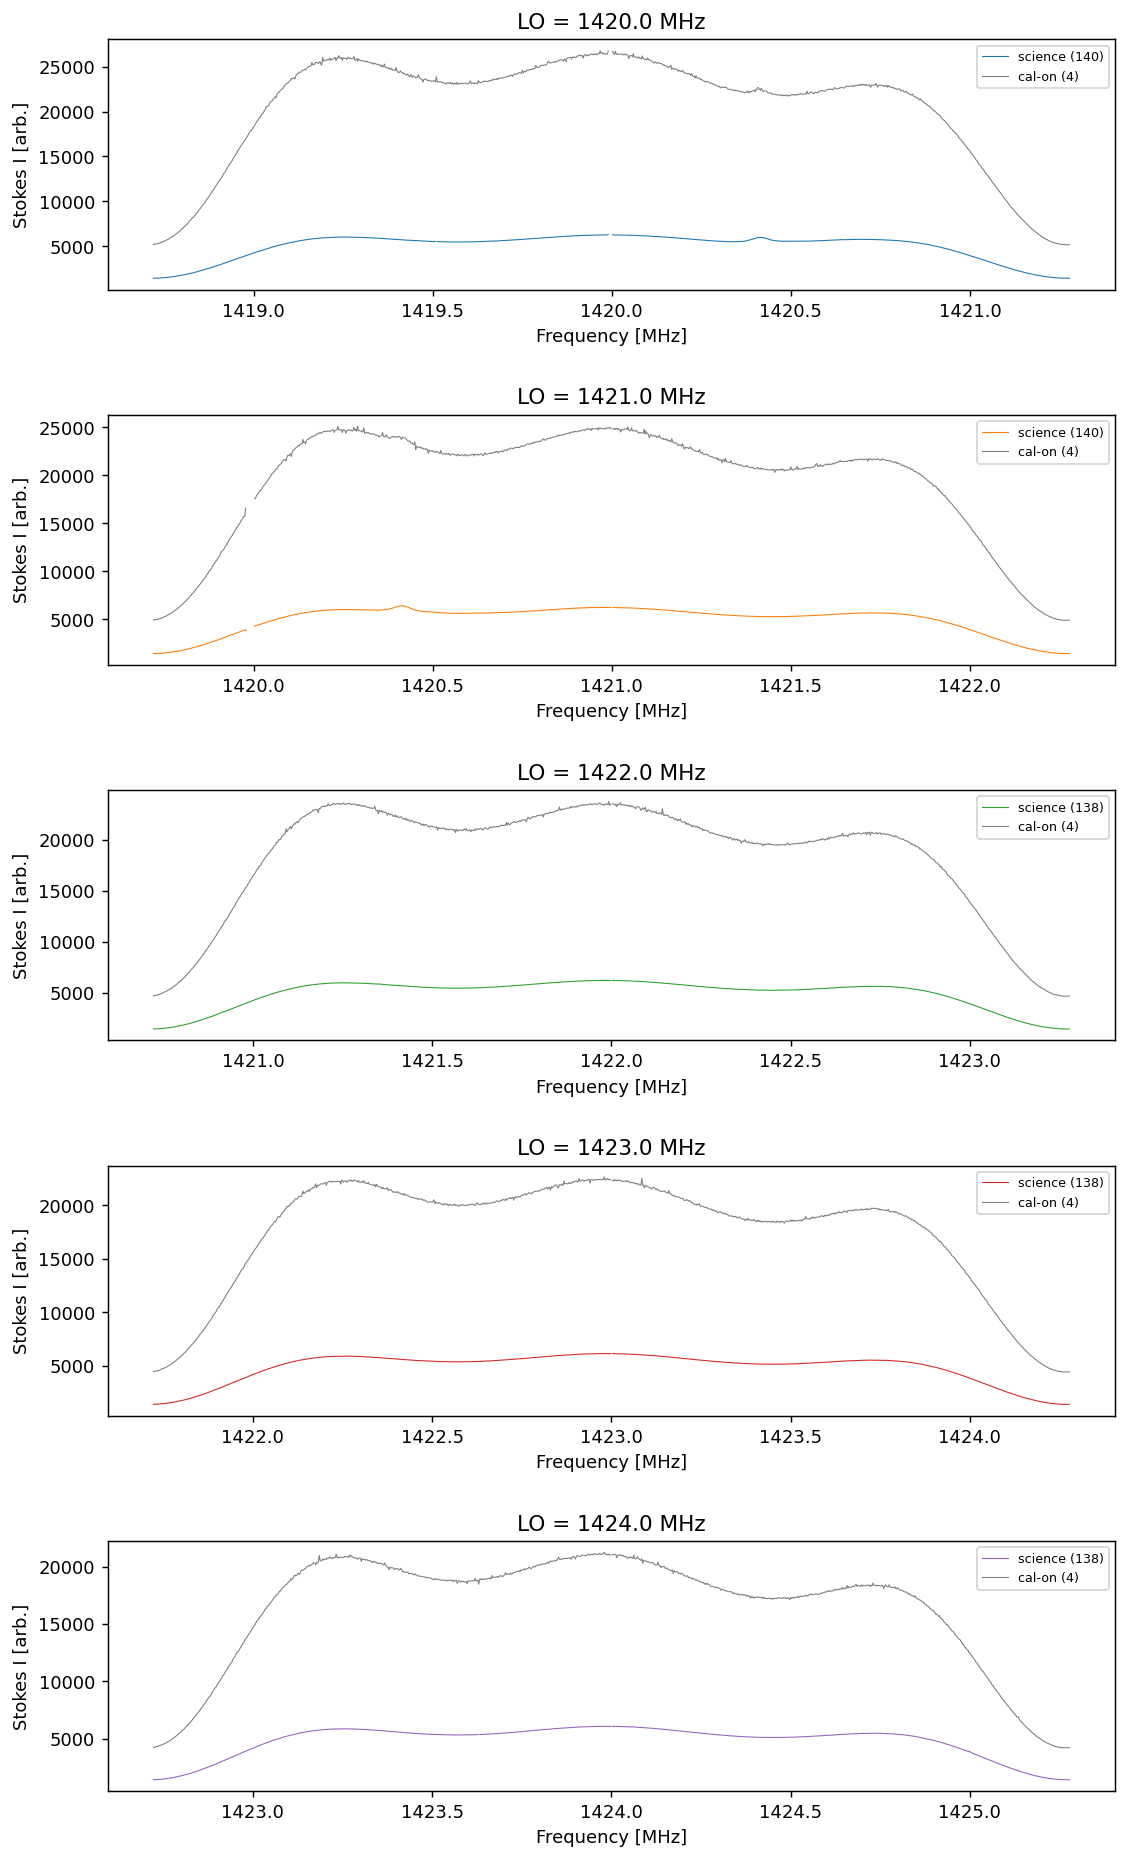

In [5]:
fig, axes = plt.subplots(len(lo_unique), 1, figsize=(10, 3.5 * len(lo_unique)),
                         gridspec_kw={'hspace': 0.5})
if len(lo_unique) == 1:
    axes = [axes]

for i, lo in enumerate(lo_unique):
    sci_mask = sci & (lo_mhz == lo)
    cal_mask = cal & (lo_mhz == lo)
    mean_sci = np.nanmean(stokes_I[sci_mask], axis=0)
    f_sky = lo + f_bb_mhz

    ax = axes[i]
    ax.plot(f_sky, mean_sci, lw=0.6, color=f'C{i}', label=f'science ({sci_mask.sum()})')
    if cal_mask.sum() > 0:
        mean_cal = np.nanmean(stokes_I[cal_mask], axis=0)
        ax.plot(f_sky, mean_cal, lw=0.6, color='k', alpha=0.5, label=f'cal-on ({cal_mask.sum()})')
    ax.set_xlabel('Frequency [MHz]')
    ax.set_ylabel('Stokes I [arb.]')
    ax.set_title(f'LO = {lo} MHz')
    ax.legend(fontsize=7)

fig.tight_layout()
plt.show()

## 3. Pair by LO frequency and compute switched spectra

For each adjacent LO pair (lo1, lo2), compute `R = (I1 - I2) / I2`.
The overlap region (trimmed 256 kHz from each edge) isolates the line profile.

In [6]:
# Build adjacent LO pairs
lo_pairs = [(lo_unique[i], lo_unique[i+1]) for i in range(len(lo_unique)-1)]
print(f'LO pairs: {lo_pairs}')

# Channel shift for 1 MHz LO offset
lo_step_mhz = lo_unique[1] - lo_unique[0] if len(lo_unique) > 1 else 1.0
shift_ch = round(lo_step_mhz / (SAMPLE_RATE_HZ / NFFT / 1e6))
print(f'LO step: {lo_step_mhz} MHz = {shift_ch} channels')

# Edge trim: 256 kHz from each edge of overlap (avoids DC leakage halos)
EDGE_TRIM_MHZ = 0.256

pair_results = {}
for lo1, lo2 in lo_pairs:
    # Get science dumps at each LO
    idx1 = np.where(sci & (lo_mhz == lo1))[0]
    idx2 = np.where(sci & (lo_mhz == lo2))[0]
    n_p = min(len(idx1), len(idx2))
    
    I1 = stokes_I[idx1[:n_p]]  # (n_p, N_CH)
    I2 = stokes_I[idx2[:n_p]]
    
    # Frequency-switched ratio
    R = (I1 - I2) / I2
    R_mean = np.nanmean(R, axis=0)
    R_std = np.nanstd(R, axis=0) / np.sqrt(n_p)
    
    # Sky frequency axes
    f_sky_1 = lo1 + f_bb_mhz
    f_sky_2 = lo2 + f_bb_mhz
    
    # Overlap region, trimmed by EDGE_TRIM_MHZ on each side
    f_overlap_lo = max(f_sky_1[0], f_sky_2[0]) + EDGE_TRIM_MHZ
    f_overlap_hi = min(f_sky_1[-1], f_sky_2[-1]) - EDGE_TRIM_MHZ
    overlap_mask = (f_sky_1 >= f_overlap_lo) & (f_sky_1 <= f_overlap_hi)
    
    pair_results[(lo1, lo2)] = {
        'R_mean': R_mean, 'R_std': R_std,
        'f_sky_1': f_sky_1, 'f_sky_2': f_sky_2,
        'overlap_mask': overlap_mask, 'n_pairs': n_p,
    }
    
    print(f'  ({lo1}, {lo2}): {n_p} pairs, '
          f'usable [{f_overlap_lo:.2f}, {f_overlap_hi:.2f}] MHz '
          f'(trimmed {EDGE_TRIM_MHZ*1e3:.0f} kHz edges)')

LO pairs: [(np.float64(1420.0), np.float64(1421.0)), (np.float64(1421.0), np.float64(1422.0)), (np.float64(1422.0), np.float64(1423.0)), (np.float64(1423.0), np.float64(1424.0))]
LO step: 1.0 MHz = 400 channels
  (1420.0, 1421.0): 140 pairs, usable [1419.98, 1421.02] MHz (trimmed 256 kHz edges)
  (1421.0, 1422.0): 138 pairs, usable [1420.98, 1422.02] MHz (trimmed 256 kHz edges)
  (1422.0, 1423.0): 138 pairs, usable [1421.98, 1423.02] MHz (trimmed 256 kHz edges)
  (1423.0, 1424.0): 138 pairs, usable [1422.98, 1424.02] MHz (trimmed 256 kHz edges)


/tmp/ipykernel_819211/3366126525.py:25: RuntimeWarning: Mean of empty slice
  R_mean = np.nanmean(R, axis=0)
/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


## 4. HI profiles

### 4a. Full-band R for each pair

Raw frequency-switched ratio R = (I1 - I2) / I2 across the full band.

/tmp/ipykernel_819211/3161836228.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


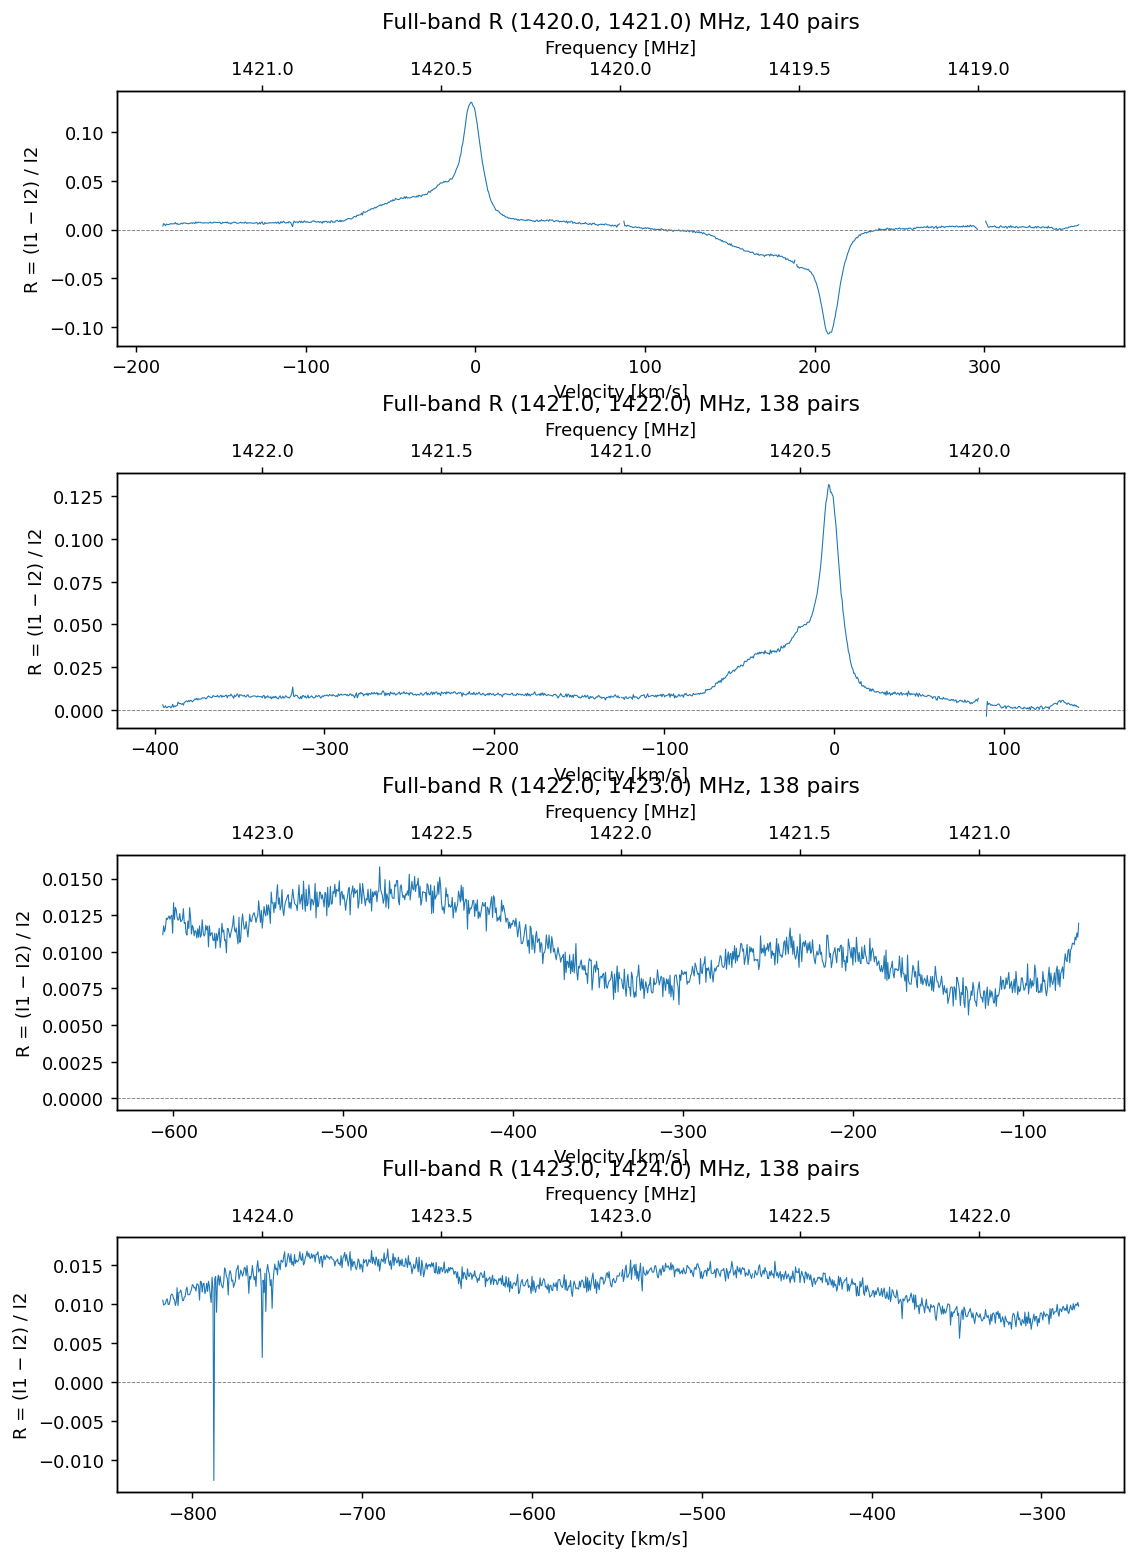

In [7]:
n_pairs_plot = len(pair_results)
fig, axes = plt.subplots(n_pairs_plot, 1, figsize=(10, 3.5 * n_pairs_plot),
                         gridspec_kw={'hspace': 0.5})
if n_pairs_plot == 1:
    axes = [axes]

for row, ((lo1, lo2), pr) in enumerate(pair_results.items()):
    ax = axes[row]
    f_sky = pr['f_sky_1']
    v_kms = C_KMS * (1 - f_sky / HI_REST_MHZ)
    ax.plot(v_kms, pr['R_mean'], lw=0.6, color='C0')
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.set_xlabel('Velocity [km/s]')
    ax.set_ylabel('R = (I1 − I2) / I2')
    ax.set_title(f'Full-band R ({lo1}, {lo2}) MHz, {pr["n_pairs"]} pairs')

    ax_freq = ax.twiny()
    v_lo, v_hi = ax.get_xlim()
    ax_freq.set_xlim(HI_REST_MHZ * (1 - v_lo / C_KMS),
                     HI_REST_MHZ * (1 - v_hi / C_KMS))
    ax_freq.set_xlabel('Frequency [MHz]')
    ax_freq.ticklabel_format(axis='x', useOffset=False)

fig.tight_layout()
plt.show()

### 4b. R in overlap region only

/tmp/ipykernel_819211/71762405.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


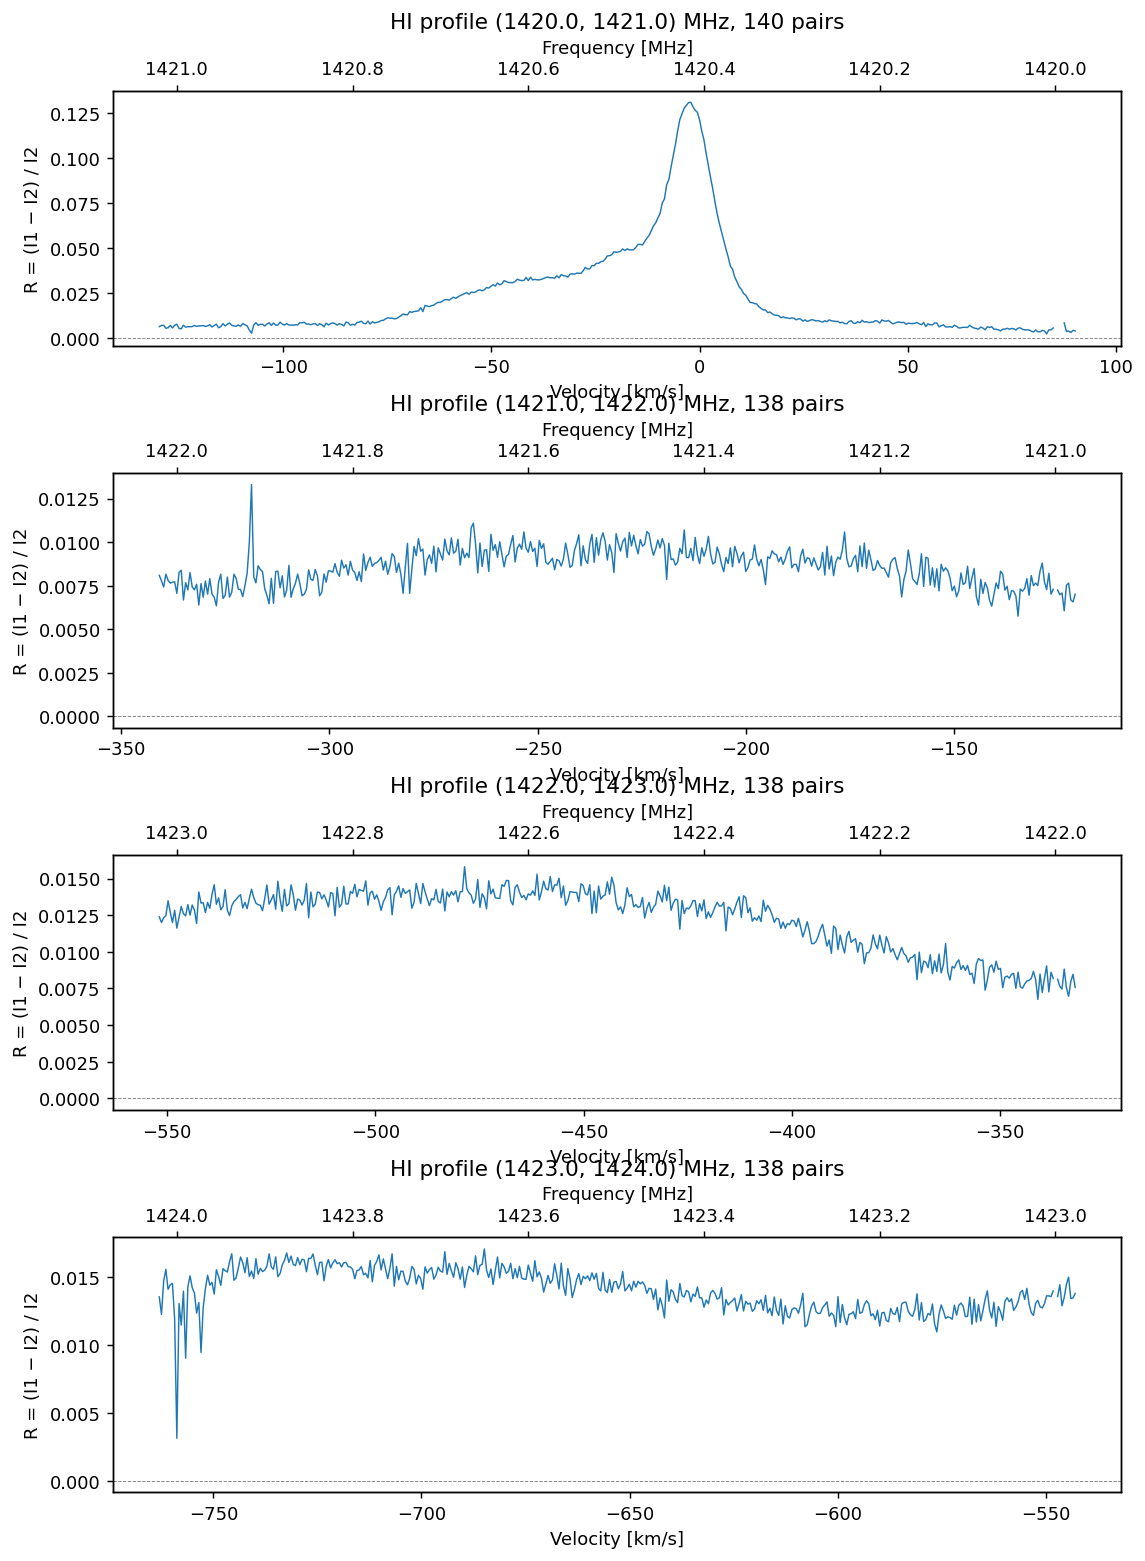

In [8]:
n_pairs_plot = len(pair_results)
fig, axes = plt.subplots(n_pairs_plot, 1, figsize=(10, 3.5 * n_pairs_plot),
                         gridspec_kw={'hspace': 0.5})
if n_pairs_plot == 1:
    axes = [axes]

for row, ((lo1, lo2), pr) in enumerate(pair_results.items()):
    f1 = pr['f_sky_1']
    mask = pr['overlap_mask']

    ax = axes[row]
    f_sky = f1[mask]
    v_kms = C_KMS * (1 - f_sky / HI_REST_MHZ)
    profile = pr['R_mean'][mask]
    ax.plot(v_kms, profile, lw=0.8, color='C0')
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.set_xlabel('Velocity [km/s]')
    ax.set_ylabel('R = (I1 − I2) / I2')
    ax.set_title(f'HI profile ({lo1}, {lo2}) MHz, {pr["n_pairs"]} pairs')

    # Top axis: frequency
    ax_freq = ax.twiny()
    v_lo, v_hi = ax.get_xlim()
    f_lo = HI_REST_MHZ * (1 - v_lo / C_KMS)
    f_hi = HI_REST_MHZ * (1 - v_hi / C_KMS)
    ax_freq.set_xlim(f_lo, f_hi)
    ax_freq.set_xlabel('Frequency [MHz]')
    ax_freq.ticklabel_format(axis='x', useOffset=False)

fig.tight_layout()
plt.show()

### 4c. All pairs combined

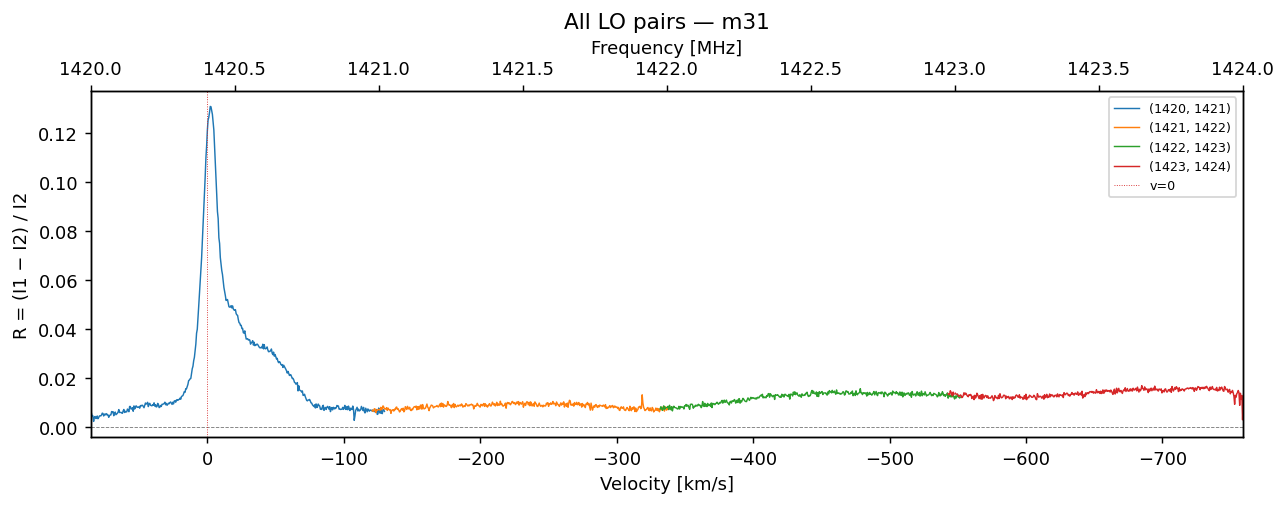

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))

for i, ((lo1, lo2), pr) in enumerate(pair_results.items()):
    mask = pr['overlap_mask']
    f_sky = pr['f_sky_1'][mask]
    v_kms = C_KMS * (1 - f_sky / HI_REST_MHZ)
    ax.plot(v_kms, pr['R_mean'][mask], lw=0.8, color=f'C{i}',
            label=f'({lo1:.0f}, {lo2:.0f})')

ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.axvline(0, color='C3', lw=0.5, ls=':', label='v=0')
ax.set_xlabel('Velocity [km/s]')
ax.set_ylabel('R = (I1 − I2) / I2')
ax.set_title(f'All LO pairs — {TARGET}')
ax.legend(fontsize=7)

# Limit to 1420–1424 MHz
f_lo_lim, f_hi_lim = 1420.0, 1424.0
v_lo_lim = C_KMS * (1 - f_lo_lim / HI_REST_MHZ)
v_hi_lim = C_KMS * (1 - f_hi_lim / HI_REST_MHZ)
ax.set_xlim(v_lo_lim, v_hi_lim)

ax_freq = ax.twiny()
ax_freq.set_xlim(f_lo_lim, f_hi_lim)
ax_freq.set_xlabel('Frequency [MHz]')
ax_freq.ticklabel_format(axis='x', useOffset=False)

fig.tight_layout()
plt.show()

### 4d. Chips 1–2 (M31 velocity range)

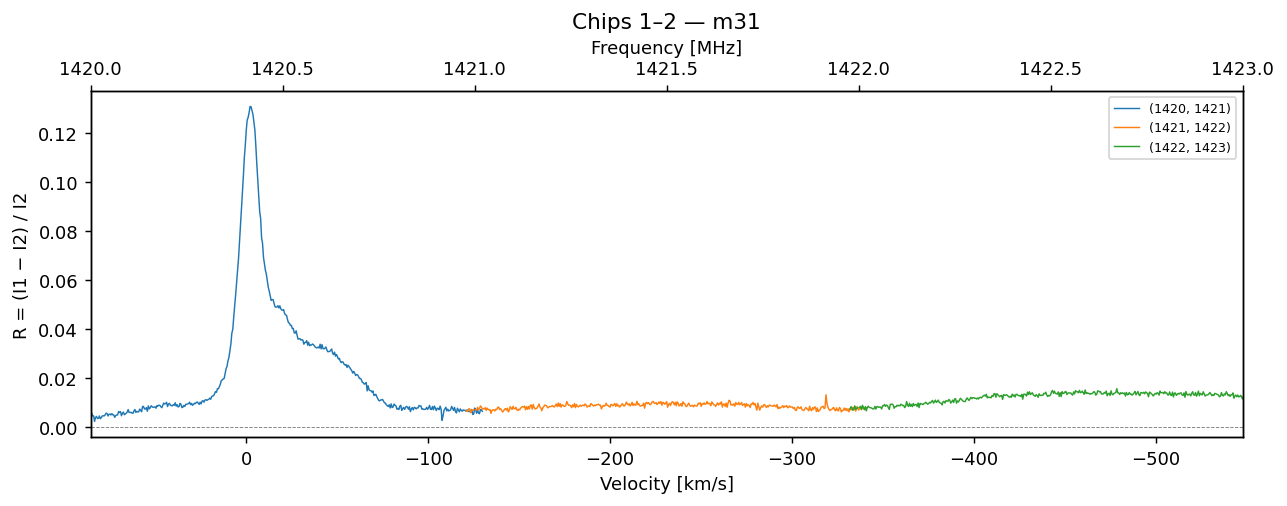

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))

for i, ((lo1, lo2), pr) in enumerate(pair_results.items()):
    if i == 3:
        continue  # skip first chip (MW) and last chip (beyond M31)

    mask = pr['overlap_mask']
    f_sky = pr['f_sky_1'][mask]
    v_kms = C_KMS * (1 - f_sky / HI_REST_MHZ)

    ax.plot(v_kms, pr['R_mean'][mask], lw=0.8, color=f'C{i}',
            label=f'({lo1:.0f}, {lo2:.0f})')

ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.set_xlabel('Velocity [km/s]')
ax.set_ylabel('R = (I1 − I2) / I2')
ax.set_title(f'Chips 1–2 — {TARGET}')
ax.legend(fontsize=7)

# Limit to 1420–1424 MHz
f_lo_lim, f_hi_lim = 1420.0, 1423.0
v_lo_lim = C_KMS * (1 - f_lo_lim / HI_REST_MHZ)
v_hi_lim = C_KMS * (1 - f_hi_lim / HI_REST_MHZ)
ax.set_xlim(v_lo_lim, v_hi_lim)

ax_freq = ax.twiny()
ax_freq.set_xlim(f_lo_lim, f_hi_lim)
ax_freq.set_xlabel('Frequency [MHz]')
ax_freq.ticklabel_format(axis='x', useOffset=False)

fig.tight_layout()
plt.show()

## 5. Summary

In [11]:
t0 = dt.datetime.fromtimestamp(unix_t[0], tz=dt.UTC)
t1 = dt.datetime.fromtimestamp(unix_t[-1], tz=dt.UTC)
wall = unix_t[-1] - unix_t[0]
cadence = float(np.median(np.diff(unix_t[sci])))

print(f'Target:     {TARGET}')
print(f'Start:      {t0:%Y-%m-%d %H:%M:%S UTC}')
print(f'End:        {t1:%Y-%m-%d %H:%M:%S UTC}')
print(f'Duration:   {wall/60:.1f} min')
print(f'Dumps:      {N} ({cal.sum()} cal + {sci.sum()} science)')
print(f'LO freqs:   {lo_unique} MHz')
print(f'Channels:   {N_CH} (dnu={df_khz:.2f} kHz)')
print(f'Cadence:    {cadence:.1f} s')
print(f'Alt range:  {alt_arr.min():.1f} - {alt_arr.max():.1f} deg')
print(f'Az range:   {az_arr.min():.1f} - {az_arr.max():.1f} deg')

Target:     m31
Start:      2026-04-16 20:03:45 UTC
End:        2026-04-17 01:55:57 UTC
Duration:   352.2 min
Dumps:      714 (20 cal + 694 science)
LO freqs:   [np.float64(1420.0), np.float64(1421.0), np.float64(1422.0), np.float64(1423.0), np.float64(1424.0)] MHz
Channels:   1024 (dnu=2.50 kHz)
Cadence:    29.7 s
Alt range:  17.1 - 79.9 deg
Az range:   288.1 - 309.6 deg


## 6. Brightness calibration

Use noise diode cal-on / cal-off to convert R into antenna temperature,
then measure SNR per chip and overall detection significance.

In [12]:
T_CAL = 12.0  # K — noise diode equivalent temperature (adjust to your value)

# --- Step 1: T_sys per LO from noise diode ---
P_on = {}
P_off = {}
T_sys = {}

for lo in lo_unique:
    on_mask = cal & (lo_mhz == lo)
    off_mask = sci & (lo_mhz == lo)
    P_on[lo] = np.nanmean(stokes_I[on_mask], axis=0)
    P_off[lo] = np.nanmean(stokes_I[off_mask], axis=0)
    delta = P_on[lo] - P_off[lo]
    T_sys[lo] = T_CAL * P_off[lo] / delta
    print(f'LO={lo} MHz: {on_mask.sum()} cal-on, {off_mask.sum()} cal-off, '
          f'median T_sys = {np.nanmedian(T_sys[lo]):.1f} K')

# --- Step 2: Convert R to antenna temperature per chip ---
print(f'\n{"="*70}')
print(f'{"Chip":<8} {"LO pair":<16} {"v_peak [km/s]":<16} {"T_A peak [K]":<14} '
      f'{"T_A noise [K]":<14} {"SNR":<8}')
print(f'{"="*70}')

for i, ((lo1, lo2), pr) in enumerate(pair_results.items()):
    mask = pr['overlap_mask']
    f_sky = pr['f_sky_1'][mask]
    v_kms = C_KMS * (1 - f_sky / HI_REST_MHZ)
    R_m = pr['R_mean'][mask]

    # T_A = R * T_sys (using first LO's T_sys in the overlap)
    T_sys_overlap = T_sys[lo1][mask]
    T_A = R_m * T_sys_overlap

    # Line-free region for baseline: |v| > 100 km/s for chip 0, edges for others
    if i == 0:
        line_free = np.abs(v_kms) > 100
    else:
        # Use outermost 20% on each side as line-free
        n_ch = len(v_kms)
        edge = max(1, n_ch // 5)
        line_free = np.zeros(n_ch, dtype=bool)
        line_free[:edge] = True
        line_free[-edge:] = True

    baseline = np.nanmedian(T_A[line_free])
    noise = np.nanstd(T_A[line_free])
    T_A_sub = T_A - baseline

    peak_idx = np.nanargmax(T_A_sub)
    peak_T = T_A_sub[peak_idx]
    peak_v = v_kms[peak_idx]
    snr = peak_T / noise if noise > 0 else 0

    pr['T_A'] = T_A_sub
    pr['T_A_noise'] = noise
    pr['v_kms_overlap'] = v_kms
    pr['f_sky_overlap'] = f_sky

    print(f'{i:<8} ({lo1:.0f}, {lo2:.0f}){"":<8} {peak_v:>+8.1f}{"":<8} '
          f'{peak_T:>8.2f}{"":<6} {noise:>8.3f}{"":<6} {snr:>6.1f}')

LO=1420.0 MHz: 4 cal-on, 140 cal-off, median T_sys = 3.8 K
LO=1421.0 MHz: 4 cal-on, 140 cal-off, median T_sys = 4.1 K
LO=1422.0 MHz: 4 cal-on, 138 cal-off, median T_sys = 4.3 K
LO=1423.0 MHz: 4 cal-on, 138 cal-off, median T_sys = 4.6 K
LO=1424.0 MHz: 4 cal-on, 138 cal-off, median T_sys = 5.0 K

Chip     LO pair          v_peak [km/s]    T_A peak [K]   T_A noise [K]  SNR     
0        (1420, 1421)             -2.1             0.55          0.004        132.7
1        (1421, 1422)           -318.7             0.03          0.004          7.0
2        (1422, 1423)           -478.6             0.02          0.012          1.3
3        (1423, 1424)           -745.6             0.02          0.010          1.8


/tmp/ipykernel_819211/2651783167.py:11: RuntimeWarning: Mean of empty slice
  P_on[lo] = np.nanmean(stokes_I[on_mask], axis=0)
/tmp/ipykernel_819211/2651783167.py:12: RuntimeWarning: Mean of empty slice
  P_off[lo] = np.nanmean(stokes_I[off_mask], axis=0)


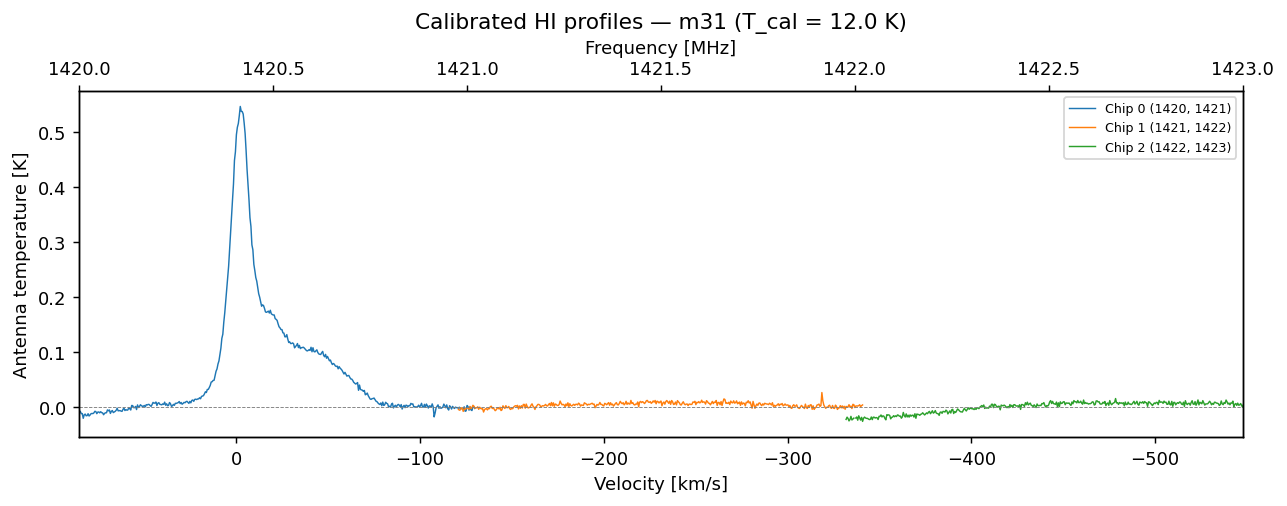

In [15]:
# --- Step 3: Plot calibrated profiles ---
fig, ax = plt.subplots(figsize=(10, 4))

for i, ((lo1, lo2), pr) in enumerate(pair_results.items()):
    if i > 2 or 'T_A' not in pr:
        continue
    ax.plot(pr['v_kms_overlap'], pr['T_A'], lw=0.8, color=f'C{i}',
            label=f'Chip {i} ({lo1:.0f}, {lo2:.0f})')

ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.set_xlabel('Velocity [km/s]')
ax.set_ylabel('Antenna temperature [K]')
ax.set_title(f'Calibrated HI profiles — {TARGET} (T_cal = {T_CAL} K)')
ax.legend(fontsize=7)

f_lo_lim, f_hi_lim = 1420.0, 1423.0
v_lo_lim = C_KMS * (1 - f_lo_lim / HI_REST_MHZ)
v_hi_lim = C_KMS * (1 - f_hi_lim / HI_REST_MHZ)
ax.set_xlim(v_lo_lim, v_hi_lim)

ax_freq = ax.twiny()
ax_freq.set_xlim(f_lo_lim, f_hi_lim)
ax_freq.set_xlabel('Frequency [MHz]')
ax_freq.ticklabel_format(axis='x', useOffset=False)

fig.tight_layout()
plt.show()